# Project Appendix
# DSC 630 Predictive Analytics
# Kevin Danh

## Initial Data Analysis

In [1]:
# Necessary libraries
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data manipulation
import pandas as pd
import numpy as np

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Model evaluation metrics
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report

These libraries were used to perform data exploration, visualization, preprocessing, model training, and evaluation. Pandas and NumPy handle data manipulation, while Matplotlib and Seaborn are used for visualization. Scikit-learn provides machine learning models and evaluation tools.

In [2]:
# Load the dataset
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.head(10)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
5,90.0,1,47,0,40,1,204000.00,2.1,132,1,1,8,1
6,75.0,1,246,0,15,0,127000.00,1.2,137,1,0,10,1
7,60.0,1,315,1,60,0,454000.00,1.1,131,1,1,10,1
8,65.0,0,157,0,65,0,263358.03,1.5,138,0,0,10,1
9,80.0,1,123,0,35,1,388000.00,9.4,133,1,1,10,1


The dataset was loaded using the Pandas library. Displaying the first 10 rows allows inspection of the dataset structure and ensures that the data was imported correctly.

In [3]:
# Check the shape of the dataset
df.shape

(299, 13)

This step checks the number of rows and columns in the dataset. The dataset contains 299 patient records and 13 variables, including clinical features and the target variable DEATH_EVENT.

In [4]:
df.nunique()

age                          47
anaemia                       2
creatinine_phosphokinase    208
diabetes                      2
ejection_fraction            17
high_blood_pressure           2
platelets                   176
serum_creatinine             40
serum_sodium                 27
sex                           2
smoking                       2
time                        148
DEATH_EVENT                   2
dtype: int64

This step counts the number of unique values in each column. This helps determine whether variables are continuous or categorical and assists in deciding which variables require scaling or encoding.

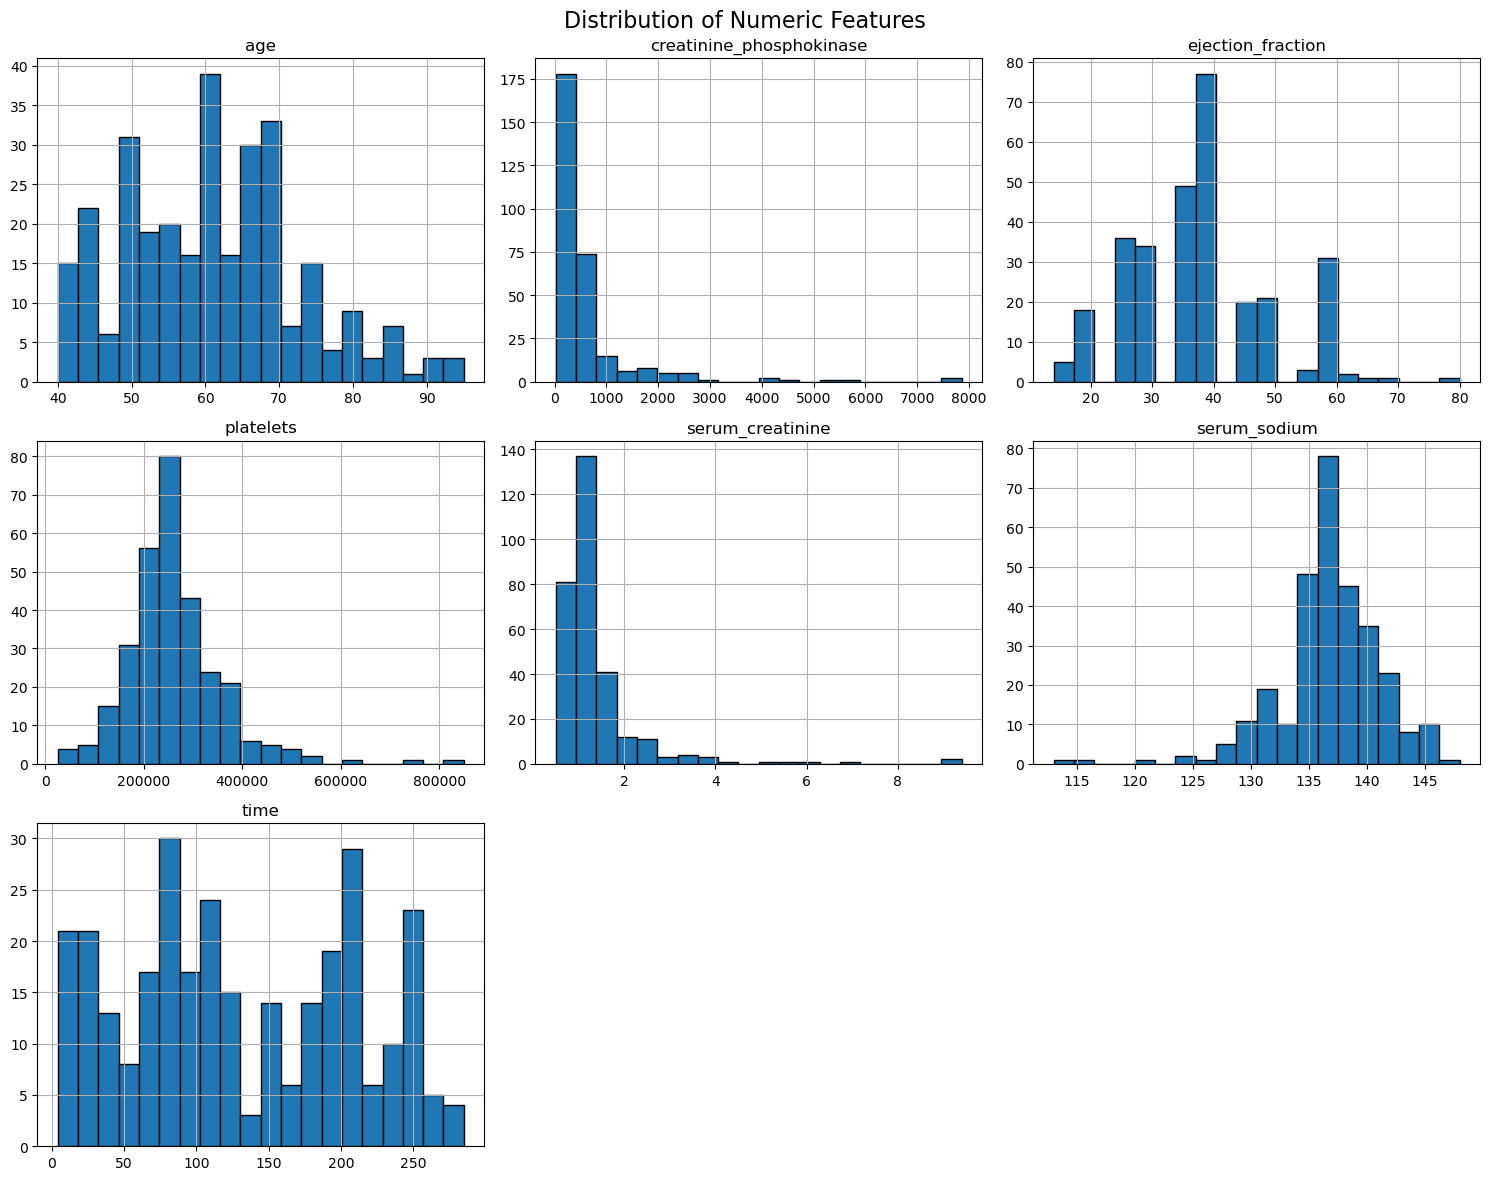

In [5]:
# Display the age distribution of patients.
# Select numeric columns only
select_cols = df.drop(['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking', 'DEATH_EVENT'], axis=1)

# Create histograms
select_cols.hist(
    figsize=(15, 12),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

Histograms were used to visualize the distribution of continuous variables. This helps identify skewness, potential outliers, and abnormal distributions that may affect machine learning model performance.

C:\Users\Crono\AppData\Local\Temp\ipykernel_20740\3074974493.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DEATH_EVENT', data=df, palette='pastel')


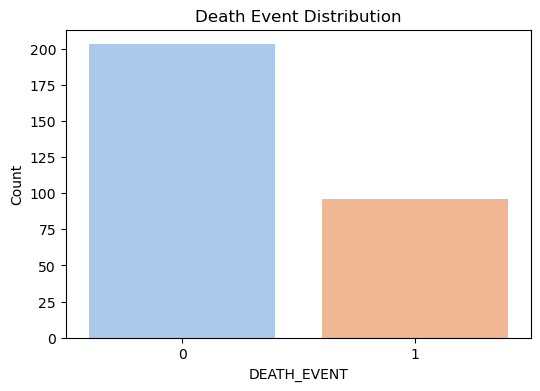

In [6]:
# Count how many patients survived vs. died.
plt.figure(figsize=(6,4))
sns.countplot(x='DEATH_EVENT', data=df, palette='pastel')
plt.title('Death Event Distribution')
plt.xlabel('DEATH_EVENT')
plt.ylabel('Count')
plt.show()

A count plot was used to visualize the number of patients who survived versus those who died. This revealed class imbalance, meaning there are more survivors than deaths.

C:\Users\Crono\AppData\Local\Temp\ipykernel_20740\3915183338.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEATH_EVENT', y='age', data=df, palette='Set2')


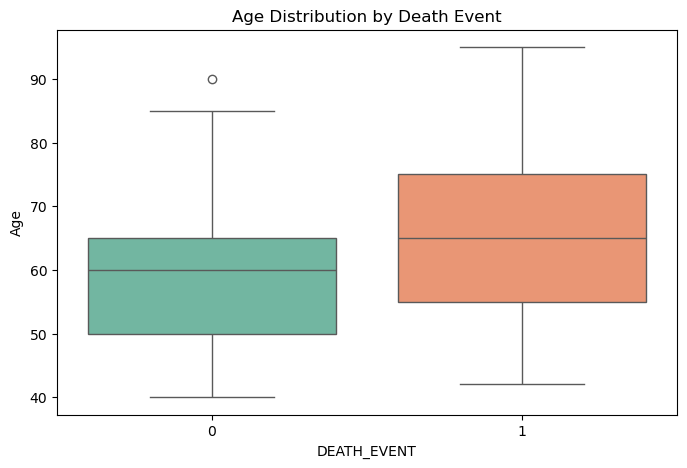

In [7]:
# Compare age distribution between survivors and non-survivors.
plt.figure(figsize=(8,5))
sns.boxplot(x='DEATH_EVENT', y='age', data=df, palette='Set2')
plt.title('Age Distribution by Death Event')
plt.xlabel('DEATH_EVENT')
plt.ylabel('Age')
plt.show()

Boxplots help visualize how age differs between patients who survived and those who died. This helps determine whether age may be a predictive factor.

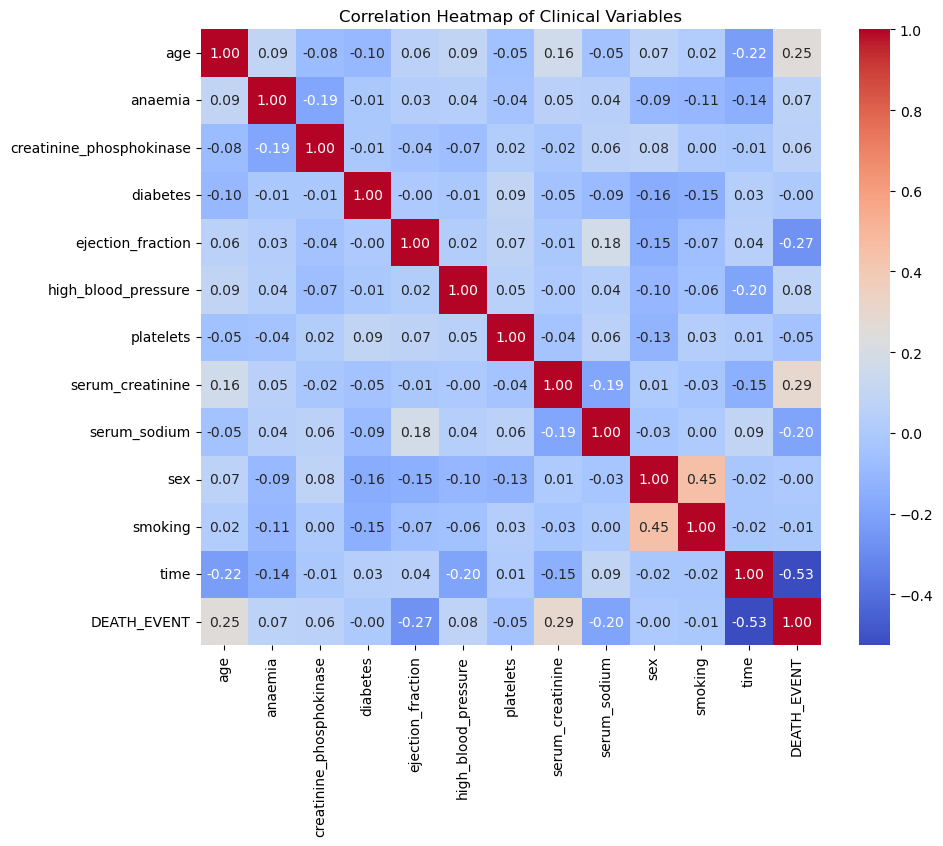

In [8]:
# Show relationships between numerical variables.
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Clinical Variables')
plt.show()

A correlation heatmap was created to examine relationships between variables. This helps identify potential predictive features and detect multicollinearity.

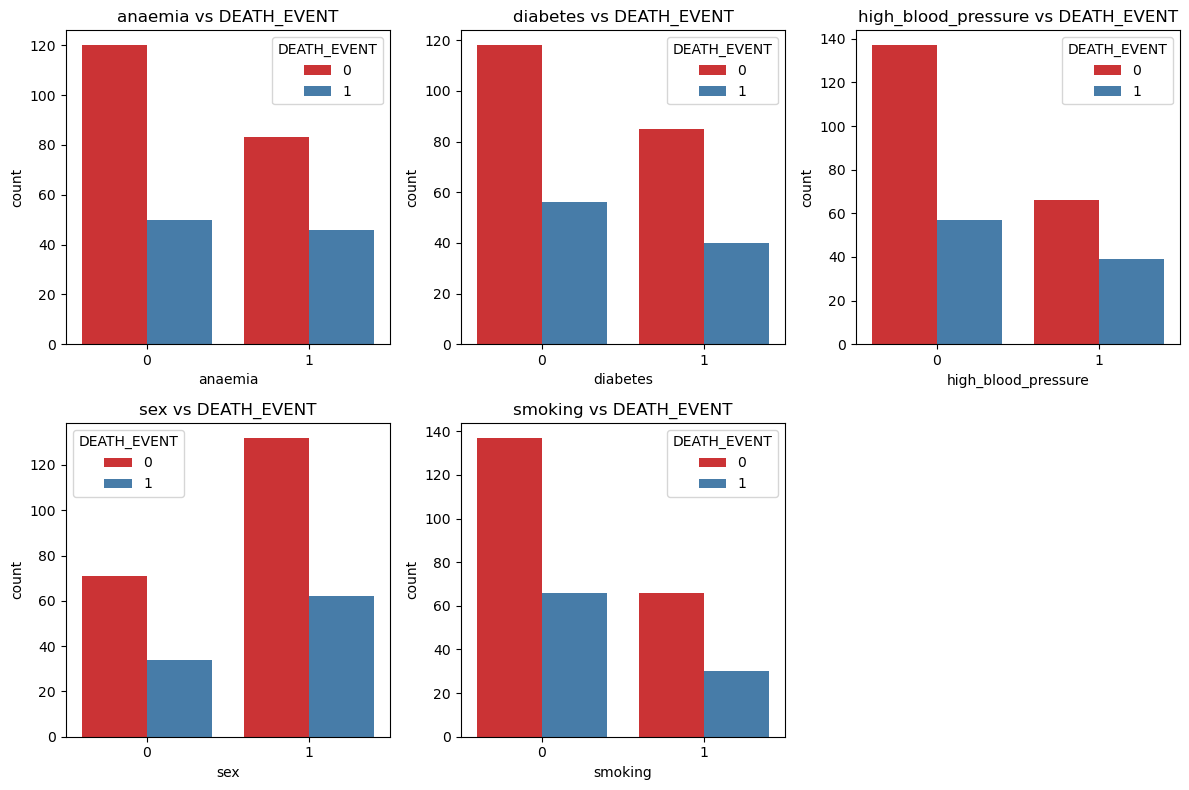

In [9]:
# Determine if certain factors leads to possible death than others
categoricals = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']

plt.figure(figsize=(12,8))
for i, col in enumerate(categoricals):
    plt.subplot(2,3,i+1)
    sns.countplot(x=col, hue='DEATH_EVENT', data=df, palette='Set1')
    plt.title(f'{col} vs DEATH_EVENT')
plt.tight_layout()
plt.show()

Count plots were used to compare categorical variables with the target variable DEATH_EVENT. This helps determine whether conditions such as diabetes or smoking status influence survival outcomes.

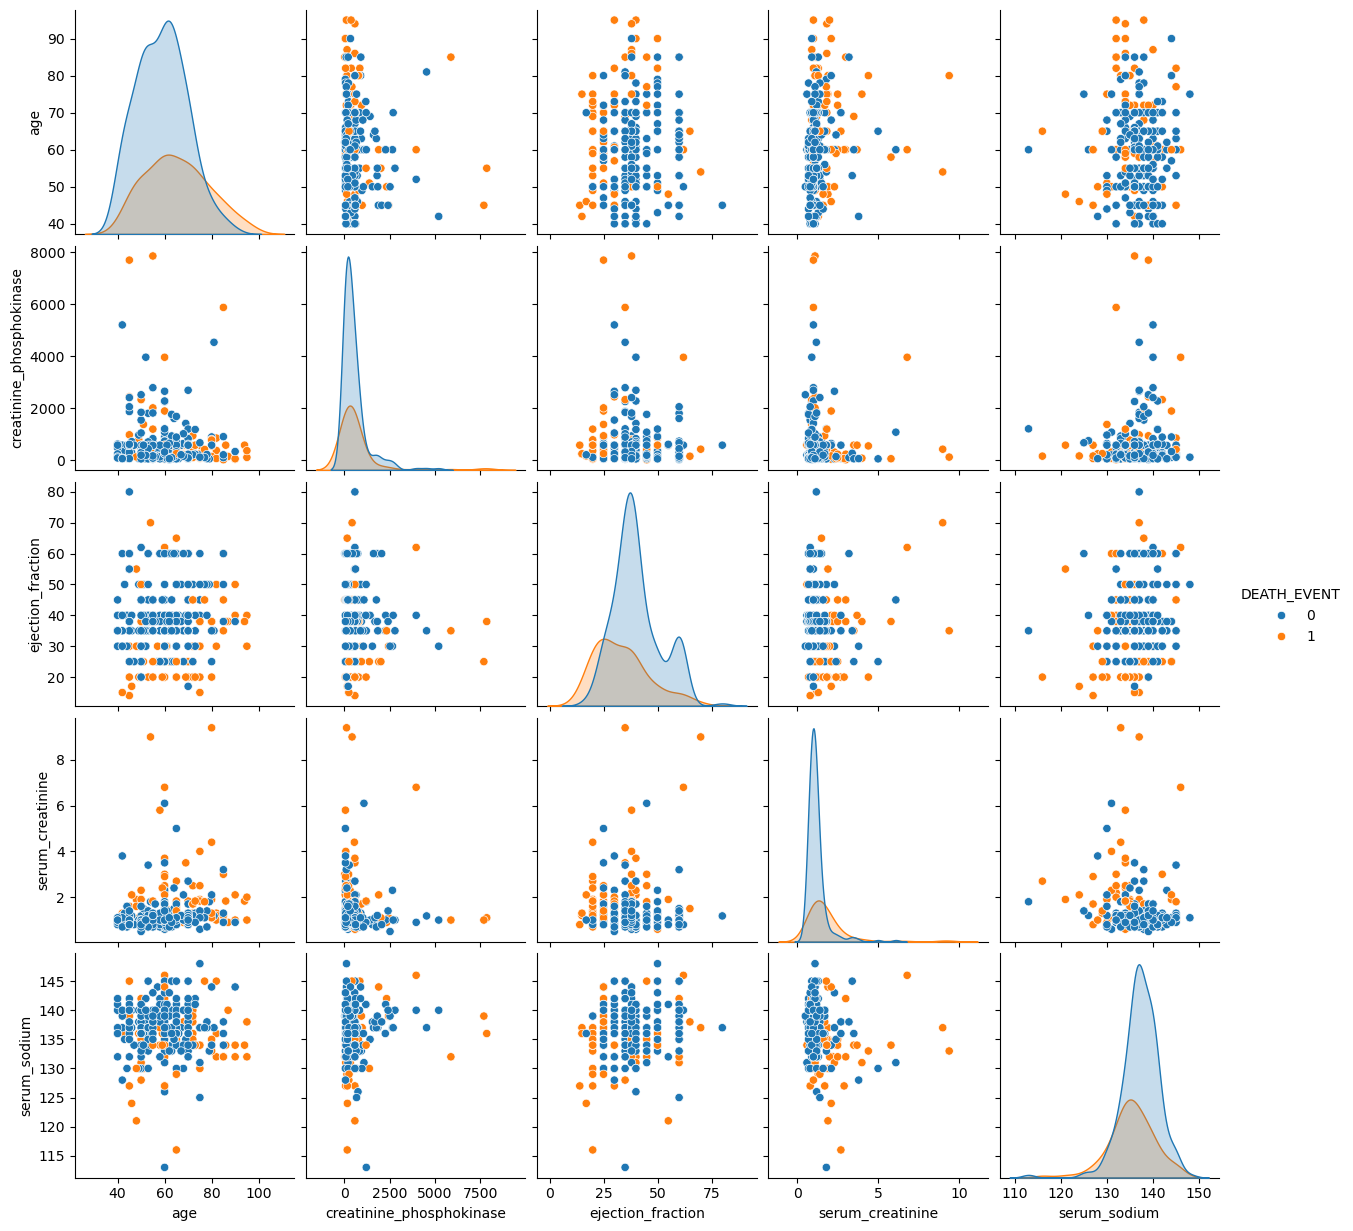

In [10]:
# Visualize relationships and distributions for multiple variables at once.
selected_vars = ['age','creatinine_phosphokinase','ejection_fraction','serum_creatinine','serum_sodium','DEATH_EVENT']
sns.pairplot(df[selected_vars], hue='DEATH_EVENT')
plt.show()

Pair plots visualize relationships between several variables simultaneously. This allows identification of potential clusters or patterns associated with patient outcomes.

## Data Modeling

In [11]:
# Prep the data
# Show types of data
df.dtypes

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

In [12]:
# Show if there is any null values present
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

This step confirms that the dataset contains no missing values, meaning no imputation was required.

In [13]:
# Handle skewed features using
# Calculate skewness
skew_values = select_cols.skew()

print(skew_values)

age                         0.423062
creatinine_phosphokinase    4.463110
ejection_fraction           0.555383
platelets                   1.462321
serum_creatinine            4.455996
serum_sodium               -1.048136
time                        0.127803
dtype: float64


Skewness was calculated to detect highly skewed variables that could negatively affect model performance.

In [14]:
# Transform extremely skewed features
df['creatinine_phosphokinase'] = np.log1p(df['creatinine_phosphokinase'])
df['serum_creatinine'] = np.log1p(df['serum_creatinine'])

Log transformations were applied to highly skewed variables to reduce the influence of extreme values and improve model stability.

In [15]:
print(df.skew())

age                         0.423062
anaemia                     0.278261
creatinine_phosphokinase    0.422715
diabetes                    0.333929
ejection_fraction           0.555383
high_blood_pressure         0.626732
platelets                   1.462321
serum_creatinine            2.313207
serum_sodium               -1.048136
sex                        -0.626732
smoking                     0.770349
time                        0.127803
DEATH_EVENT                 0.770349
dtype: float64


In [16]:
# Split the data into training and test set
# Continuous data will be scaled later but not categorical data for interpretability
binary_cols = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking', 'DEATH_EVENT']

# Only numeric continuous columns to scale
numeric_features = df.columns.drop(binary_cols)

X = df.drop(columns=['DEATH_EVENT'])
y = df['DEATH_EVENT']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

# Scale the continous columns
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

The dataset was divided into 80% training data and 20% testing data. Stratification ensures the same proportion of deaths and survivors exists in both sets. Continuous features were standardized using StandardScaler to ensure variables have comparable scales for machine learning algorithms such as logistic regression.

In [17]:
# Fit the logistic regression model
# Use 'balanced' parameter because the target variable contains more people alive than deceased
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [18]:
# Test the model's predictability
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1]

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

=== Logistic Regression ===
Accuracy: 0.85
ROC-AUC: 0.9165596919127086
Confusion Matrix:
 [[36  5]
 [ 4 15]]
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        41
           1       0.75      0.79      0.77        19

    accuracy                           0.85        60
   macro avg       0.82      0.83      0.83        60
weighted avg       0.85      0.85      0.85        60



In [19]:
# Create a random forest model
rf = RandomForestClassifier(
    n_estimators=100,            # number of trees
    random_state=0,
    class_weight='balanced'
)

# Train the model
rf.fit(X_train, y_train)

# Test predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Evaluate
print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.8833333333333333
ROC-AUC: 0.9358151476251604
Confusion Matrix:
 [[38  3]
 [ 4 15]]
              precision    recall  f1-score   support

           0       0.90      0.93      0.92        41
           1       0.83      0.79      0.81        19

    accuracy                           0.88        60
   macro avg       0.87      0.86      0.86        60
weighted avg       0.88      0.88      0.88        60



Random forest was used because it handles nonlinear relationships, outliers, and feature interactions effectively.

In [20]:
# Show feature importance
import pandas as pd
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("Top Features:\n", rf_importance.head(10))

Top Features:
                      Feature  Importance
11                      time    0.325923
7           serum_creatinine    0.170395
4          ejection_fraction    0.125608
2   creatinine_phosphokinase    0.084331
0                        age    0.081791
6                  platelets    0.072687
8               serum_sodium    0.071694
5        high_blood_pressure    0.016057
1                    anaemia    0.015722
10                   smoking    0.013870


In [21]:
# Create a gradient boosting model
gb = GradientBoostingClassifier(
    n_estimators=100,          # number of trees
    learning_rate=0.1,         # step size shrinkage
    max_depth=3,               # depth of individual trees
    random_state=0
)

# Train the model
gb.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

# Evaluate
print("=== Gradient Boosting ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

=== Gradient Boosting ===
Accuracy: 0.8833333333333333
ROC-AUC: 0.9460847240051348
Confusion Matrix:
 [[38  3]
 [ 4 15]]
              precision    recall  f1-score   support

           0       0.90      0.93      0.92        41
           1       0.83      0.79      0.81        19

    accuracy                           0.88        60
   macro avg       0.87      0.86      0.86        60
weighted avg       0.88      0.88      0.88        60



Gradient boosting was applied to improve predictive performance by sequentially building models that correct errors from previous models.

In [22]:
# Show feature importance
gb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': gb.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("Top Features:\n", gb_importance.head(10))

Top Features:
                      Feature  Importance
11                      time    0.506230
4          ejection_fraction    0.130270
7           serum_creatinine    0.119813
2   creatinine_phosphokinase    0.080164
8               serum_sodium    0.050399
6                  platelets    0.048038
0                        age    0.043189
5        high_blood_pressure    0.009062
9                        sex    0.006453
10                   smoking    0.005162


Metrics used:
Accuracy, Recall, Precision, F1 Score, ROC-AUC, Confusion Matrix

These metrics provide a comprehensive evaluation of classification performance, especially when class imbalance exists. Feature importance from tree-based models helps identify which clinical variables contribute most to predicting heart failure outcomes.